In [1]:

import cfad
from pathlib import Path
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

#from statsmodels.stats.power import TTestIndPower
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'pdf.fonttype': 42,  # Ensures fonts are editable in Adobe Illustrator
    'ps.fonttype': 42,
    'axes.spines.top': False,   # "Despining" for a cleaner look
    'axes.spines.right': False
})
output_dir = r"Z:\Saij\Data\Checkerboard\Results"

In [2]:

vep_df = pd.read_csv(r"Z:\Saij\Data\Checkerboard\nVEP.csv")

In [3]:
vep_df = vep_df[~vep_df["Mouse"].isin([6, 10, 11])]
vep_df

,Mouse,Sc Channel,Depth (µm),Latency (s),nVEP (µV),Treatment Group
0,2,265,3060.0,0.120,-5.552586,Vehicle
1,3,317,2730.0,0.144,-2.923245,Psilocybin
2,4,315,2715.0,0.148,-4.461076,Vehicle
3,5,223,3105.0,0.137,-7.920428,Psilocybin
5,7,382,3585.0,0.113,-7.361012,Psilocybin
6,8,251,2955.0,0.111,-8.637461,Psilocybin
7,9,266,3075.0,0.110,-7.655586,Vehicle
10,12,249,2940.0,0.115,-11.212459,Vehicle


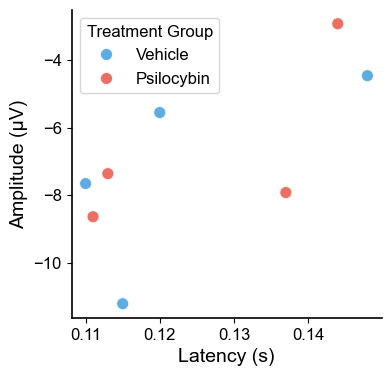

In [4]:
fig, ax = plt.subplots(figsize = (4, 4))
sns.scatterplot(
    data = vep_df,
    x='Latency (s)', 
    y='nVEP (µV)', 
    hue='Treatment Group', 
    palette=['#3498db', '#e74c3c'], 
    s=75, 
    alpha=0.8
)
ax.set(ylabel = "Amplitude (µV)")
plt.savefig(
    output_dir + r'\nVEP_latency_scatter.png', 
    dpi=300, 
    bbox_inches='tight',
    format='png' # Optional: implicitly derived from the filename
)

plt.show()


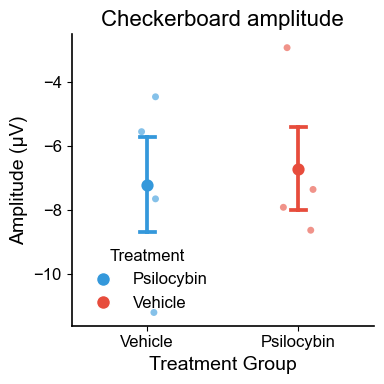

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))

# 2. Background Scatter Plot (Raw Data)
sns.stripplot(
    data=vep_df, 
    x='Treatment Group', 
    y='nVEP (µV)', 
    hue='Treatment Group',   
    palette=['#3498db', '#e74c3c'],    
    alpha=0.6,               
    jitter=True,       
    zorder=1,          
    legend=False,            
    ax=ax
)

# 3. Overlay Mean + SEM
sns.pointplot(
    data=vep_df, 
    x='Treatment Group', 
    y='nVEP (µV)', 
    hue='Treatment Group',   
    palette=['#3498db', '#e74c3c'],    
    estimator='mean',   
    errorbar=('se', 1), 
    capsize=0.1,        
    linestyle='none',         
    zorder=2,
    legend=False,            
    ax=ax
)
# 4. NEW: Create and add the Custom Legend
# Define the visual 'handles' (the icons) that will appear in the legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Psilocybin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Vehicle')
]

# Attach the legend to the axis
ax.legend(handles=legend_handles, title='Treatment', loc='lower left', frameon= False)

ax.set(ylabel = "Amplitude (μV)")

# Polish the labels and title
plt.title('Checkerboard amplitude')
plt.tight_layout()
plt.savefig(
    output_dir + r'\nVEP_between_groups.png', 
    dpi=300, 
    bbox_inches='tight',
    format='png' # Optional: implicitly derived from the filename
)



plt.show()

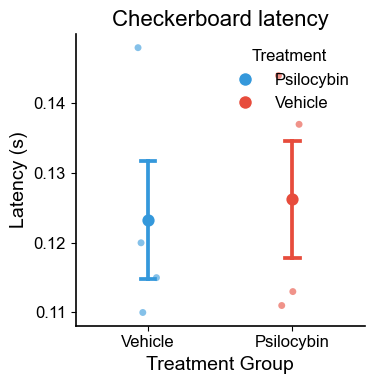

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))

# 2. Background Scatter Plot (Raw Data)
sns.stripplot(
    data=vep_df, 
    x='Treatment Group', 
    y='Latency (s)', 
    hue='Treatment Group',   
    palette=['#3498db', '#e74c3c'],    
    alpha=0.6,               
    jitter=True,       
    zorder=1,          
    legend=False,            
    ax=ax
)

# 3. Overlay Mean + SEM
sns.pointplot(
    data=vep_df, 
    x='Treatment Group', 
    y='Latency (s)', 
    hue='Treatment Group',   
    palette=['#3498db', '#e74c3c'],    
    estimator='mean',   
    errorbar=('se', 1), 
    capsize=0.1,        
    linestyle='none',         
    zorder=2,
    legend=False,            
    ax=ax
)

# 4. NEW: Create and add the Custom Legend
# Define the visual 'handles' (the icons) that will appear in the legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Psilocybin'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Vehicle')
]

# Attach the legend to the axis
ax.legend(handles=legend_handles, title='Treatment', loc='upper right', frameon= False)





# Polish the labels and title
plt.title('Checkerboard latency')
plt.tight_layout()

plt.savefig(
    output_dir + r'\latency_between_groups.png', 
    dpi=300, 
    bbox_inches='tight',
    format='png' # Optional: implicitly derived from the filename
)



plt.show()

In [7]:
stats.pearsonr(vep_df["Latency (s)"], vep_df["nVEP (µV)"])

PearsonRResult(statistic=np.float64(0.6917710263110213), pvalue=np.float64(0.057327893781888864))

In [8]:
amplitude_group_stats = vep_df.groupby("Treatment Group")["nVEP (µV)"].agg(["mean", "std", "count"])

amplitude_group_stats

,mean,std,count
Treatment Group,,,
Psilocybin,-6.710537,2.578344,4
Vehicle,-7.220426,2.973292,4


In [9]:
latency_group_stats = vep_df.groupby("Treatment Group")["Latency (s)"].agg(["mean", "std", "count"])

latency_group_stats

,mean,std,count
Treatment Group,,,
Psilocybin,0.12625,0.016721,4
Vehicle,0.12325,0.016998,4


In [10]:
Psilo_amplitude = vep_df[vep_df["Treatment Group"] == "Psilocybin"]["nVEP (µV)"]
Vehicle_amplitude = vep_df[vep_df["Treatment Group"] == "Vehicle"]["nVEP (µV)"]

In [11]:
print("Variance of vehicle amplitude is", np.var(Vehicle_amplitude))
print("Variance of treamtent amplitude is", np.var(Psilo_amplitude))


Variance of vehicle amplitude is 6.630348226746749
Variance of treamtent amplitude is 4.985892072388888


In [12]:
stats.levene(Psilo_amplitude, Vehicle_amplitude)

LeveneResult(statistic=np.float64(0.22699523920953638), pvalue=np.float64(0.6506152437206463))

In [13]:
stats.shapiro(Vehicle_amplitude)

ShapiroResult(statistic=np.float64(0.9387893652630088), pvalue=np.float64(0.6469583560307942))

In [14]:
stats.shapiro(Psilo_amplitude)

ShapiroResult(statistic=np.float64(0.8103980189318717), pvalue=np.float64(0.12221327630760853))

In [15]:
stats.ttest_ind(Psilo_amplitude, Vehicle_amplitude, equal_var = True)

TtestResult(statistic=np.float64(0.2591219630731284), pvalue=np.float64(0.8042021153991523), df=np.float64(6.0))

In [16]:

Psilo_latency = vep_df[vep_df["Treatment Group"] == "Psilocybin"]["Latency (s)"]
Vehicle_latency = vep_df[vep_df["Treatment Group"] == "Vehicle"]["Latency (s)"]




In [17]:
print("Variance of vehicle latency is", np.var(Vehicle_latency))
print("Variance of treamtent latency is", np.var(Psilo_latency))


Variance of vehicle latency is 0.00021668750000000098
Variance of treamtent latency is 0.00020968750000000073


In [18]:
stats.levene(Psilo_latency, Vehicle_latency)

LeveneResult(statistic=np.float64(0.2581211589113211), pvalue=np.float64(0.6295463553277089))

In [19]:
stats.shapiro(Vehicle_latency)

ShapiroResult(statistic=np.float64(0.837819299572099), pvalue=np.float64(0.18912012622041702))

In [20]:
stats.shapiro(Psilo_latency)

ShapiroResult(statistic=np.float64(0.848148630666097), pvalue=np.float64(0.22022087499221987))

In [21]:
stats.ttest_ind(Psilo_latency, Vehicle_latency, equal_var = True)

TtestResult(statistic=np.float64(0.2516436731940104), pvalue=np.float64(0.8097139123897675), df=np.float64(6.0))